TASK:1 Data Cleaning and Preprocessing

In [1]:
import matplotlib.pylab as plt
import pandas as pd
import numpy as np
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Data loading and data exploration 

In [2]:
df=pd.read_csv("Telco_Customer_Churn_Dataset  (1).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Handling missing values

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')

In [10]:
df = df.drop('customerID',axis=1)

In [11]:
binary_cols=['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling','Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0, 'Male':1, 'Female':0})

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['SeniorCitizen'] = le.fit_transform(df['SeniorCitizen'])

In [14]:
df = pd.get_dummies(df, columns=[col for col in categorical_cols if col not in binary_cols], drop_first=True)

In [16]:
from re import X
x = df.drop('Churn',axis=True)
y = df['Churn']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

print("Shape of x_train:", x_train.shape)
print("Shape of x_test:",x_train.shape)
print("Shape of y_train", y_train.shape)
print("Shape of y_train", y_train.shape)



Shape of x_train: (4930, 6559)
Shape of x_test: (4930, 6559)
Shape of y_train (4930,)
Shape of y_train (4930,)


TASK :2 Exploratory Data Analysis (EDA)

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_No phone service,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,0,1,0,1,0,1,29.85,0,True,...,False,False,False,False,False,False,False,False,False,False
1,1,0,0,0,34,1,0,56.95,0,False,...,False,False,False,False,False,False,False,False,False,False
2,1,0,0,0,2,1,1,53.85,1,False,...,False,False,False,False,False,False,False,False,False,False
3,1,0,0,0,45,0,0,42.30,0,True,...,False,False,False,False,False,False,False,False,False,False
4,0,0,0,0,2,1,1,70.70,1,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,0.265370
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,1.000000


In [19]:
df.info

<bound method DataFrame.info of       gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      PaperlessBilling  MonthlyCharges  Churn  MultipleLines_No phone service  

Churn Rate:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


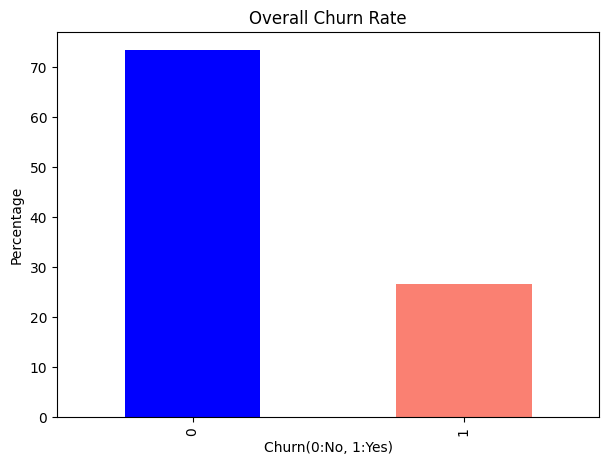

In [21]:
churn_rate = df['Churn'].value_counts(normalize=True)*100
print(f"Churn Rate:\n{churn_rate}")
 
plt.figure(figsize=(7,5))
churn_rate.plot(kind='bar', color= ['blue', 'salmon'])
plt.title('Overall Churn Rate')
plt.xlabel('Churn(0:No, 1:Yes)')
plt.ylabel('Percentage') 
plt.show()


C:\Users\yogen\AppData\Local\Temp\ipykernel_8552\3726661674.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(


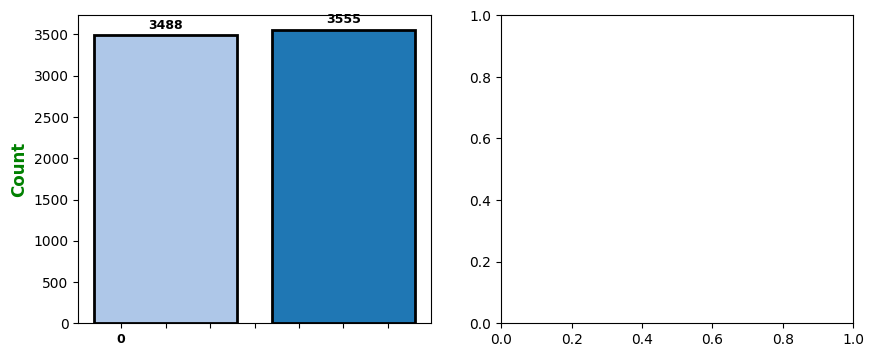

C:\Users\yogen\AppData\Local\Temp\ipykernel_8552\3726661674.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(


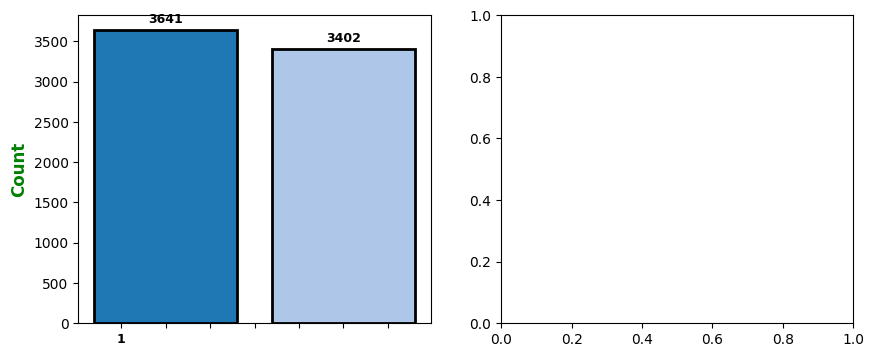

C:\Users\yogen\AppData\Local\Temp\ipykernel_8552\3726661674.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(


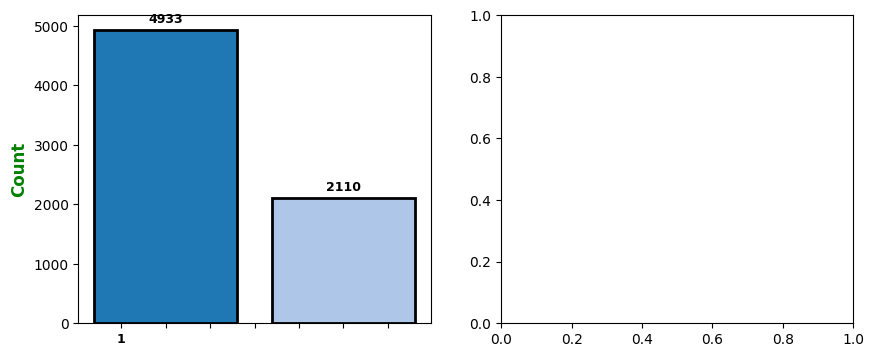

In [20]:
categorical_cols = ['gender', 'Partner', 'Dependents']   # changed variables here

for cat_cols in categorical_cols:

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # 1. We create our dataframe that contains our data to be displayed.
    df_plot_moment = df[cat_cols].value_counts().to_frame()

    # 2. We generate the values of our graphs.
    values = df_plot_moment.iloc[:, 0]

    # 3. We generate the labels for our charts.
    labels = df_plot_moment.index.to_list()

    # 4. We generate the color map.
    cmap = plt.get_cmap('tab20')
    colors = cmap(np.arange(len(labels)))

    # Bar chart
    rects = ax[0].bar(
        labels,
        values,
        color=colors,
        edgecolor='black',
        linewidth=2.0
    )

    ax[0].set_ylabel(
        'Count',
        fontsize=12,
        fontweight='bold',
        color='green'
    )

    ax[0].set_xticklabels(
        labels,
        fontsize=9,
        fontweight='bold'
    )

    # function to label our bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()

            ax[0].annotate(
                text='{}'.format(height),
                xy=(rect.get_x() + rect.get_width()/2., height - 0.005),
                xytext=(0, 3),
                textcoords='offset points',
                va='bottom',
                ha='center',
                weight='bold',
                size=9,
                color='black'
            )

    autolabel(rects)  # we label our bars

    plt.show()

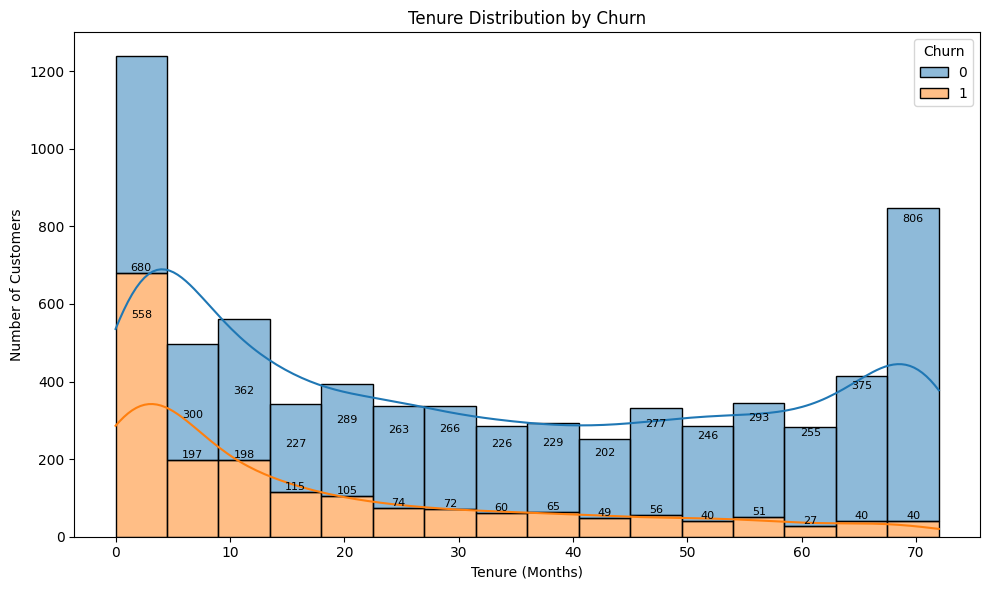

In [22]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True,
    multiple='stack'
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):  # Check for NaN values
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [25]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TotalCharges_100.2', 'TotalCharges_100.25', 'TotalCharges_100.35', 'TotalCharges_100.4', 'TotalCharges_100.8', 'TotalCharges_100.9', 'TotalCharges_1001.2', 'TotalCharges_1001.5', 'TotalCharges_1003.05', 'TotalCharges_1004.35', 'TotalCharges_1004.5', 'TotalCharges_1004

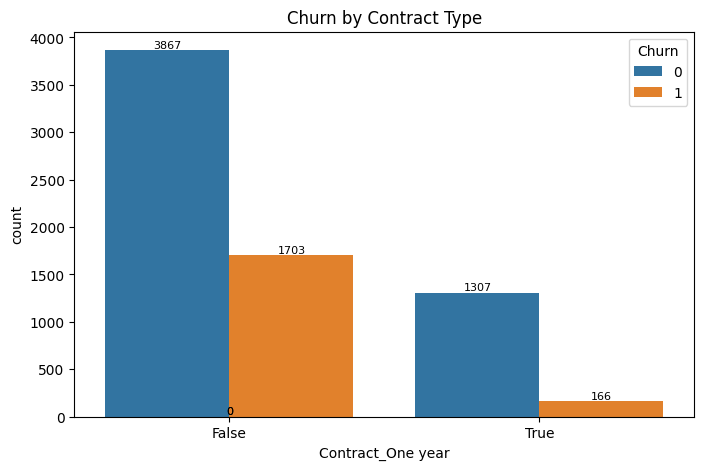

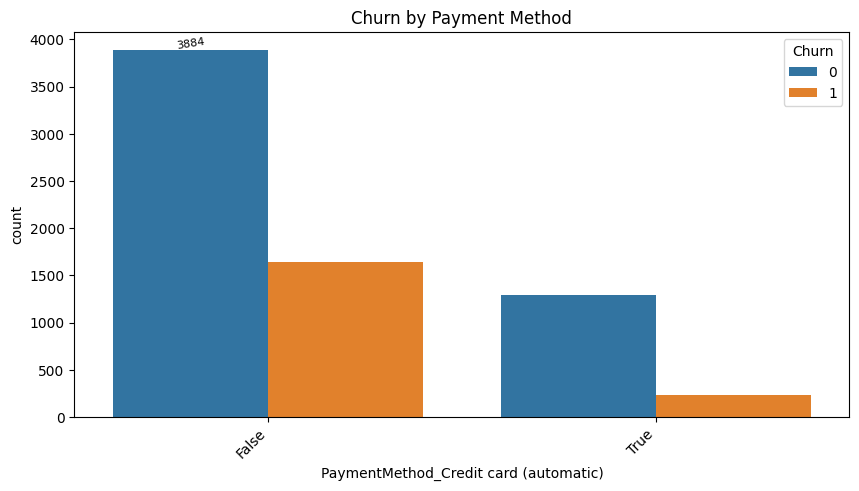

In [33]:
plt.figure(figsize=(8, 5))
ax=sns.countplot(data=df, x='Contract_One year',hue='Churn')
plt.title('Churn by Contract Type')

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.show()

#payment method vs churn
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='PaymentMethod_Credit card (automatic)',hue='Churn')
plt.title('Churn by Payment Method')
plt.xticks(rotation=45, ha= 'right')

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x()+ p.get_width() / 2.,height),
                     ha='center', va= 'bottom',
                     fontsize=8, rotation=9)
        plt.show()





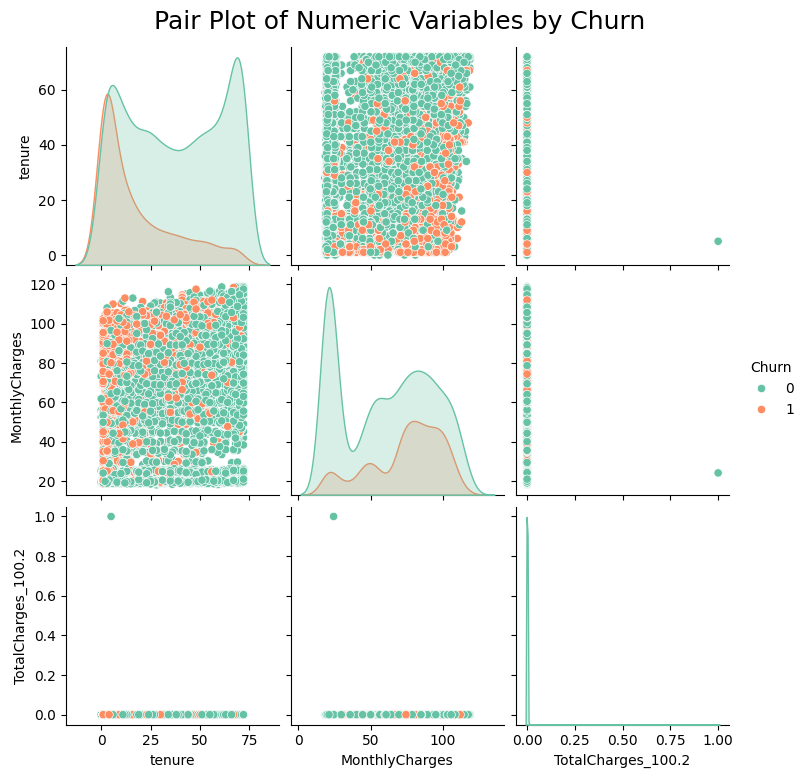

In [40]:
df['TotalCharges_100.2'] = pd.to_numeric(
    df['TotalCharges_100.2'],
    errors='coerce'
)

df.dropna(subset=['TotalCharges_100.2'], inplace=True)

numeric_variables = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges_100.2'
]

sns.pairplot(
    df,
    vars=numeric_variables,
    hue='Churn',
    palette='Set2',
    diag_kind='kde',
    height=2.5
)

plt.suptitle(
    'Pair Plot of Numeric Variables by Churn',
    y=1.03,
    fontsize=18
)

plt.show()

In [46]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TotalCharges_100.2', 'TotalCharges_100.25', 'TotalCharges_100.35', 'TotalCharges_100.4', 'TotalCharges_100.8', 'TotalCharges_100.9', 'TotalCharges_1001.2', 'TotalCharges_1001.5', 'TotalCharges_1003.05', 'TotalCharges_1004.35', 'TotalCharges_1004.5', 'TotalCharges_1004

In [47]:
for col in df.columns:
    print(col)

gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
PaperlessBilling
MonthlyCharges
Churn
MultipleLines_No phone service
MultipleLines_Yes
InternetService_Fiber optic
InternetService_No
OnlineSecurity_No internet service
OnlineSecurity_Yes
OnlineBackup_No internet service
OnlineBackup_Yes
DeviceProtection_No internet service
DeviceProtection_Yes
TechSupport_No internet service
TechSupport_Yes
StreamingTV_No internet service
StreamingTV_Yes
StreamingMovies_No internet service
StreamingMovies_Yes
Contract_One year
Contract_Two year
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check
TotalCharges_100.2
TotalCharges_100.25
TotalCharges_100.35
TotalCharges_100.4
TotalCharges_100.8
TotalCharges_100.9
TotalCharges_1001.2
TotalCharges_1001.5
TotalCharges_1003.05
TotalCharges_1004.35
TotalCharges_1004.5
TotalCharges_1004.75
TotalCharges_1005.7
TotalCharges_1006.9
TotalCharges_1007.8
TotalCharges_1007.9
TotalCharges_1008.55
TotalCharges_1008.7


In [50]:
# Feature Engineering

# Tenure in Years
df['TenureYears'] = df['tenure'] / 12

# Average Monthly Charge (if TotalCharges is meaningful)
df['AvgMonthlyCharge'] = df['TotalCharges_100.2'] / df['tenure']
df['AvgMonthlyCharge'] = df['AvgMonthlyCharge'].replace([np.inf, -np.inf], 0) # handle division by zero

# Has Multiple Services: Combine multiple "Yes/No/No internet service" columns
internet_cols = [
'InternetService_Fiber optic',
'InternetService_No',
'OnlineSecurity_No internet service',
'OnlineSecurity_Yes',
'OnlineBackup_No internet service',
'OnlineBackup_Yes',
'DeviceProtection_No internet service',
'DeviceProtection_Yes',
'TechSupport_No internet service',
'TechSupport_Yes',
'StreamingTV_No internet service',
'StreamingTV_Yes',
'StreamingMovies_No internet service',
'StreamingMovies_Yes',
    
]

for col in internet_cols:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0,
        'No internet service': 0
    })

    df['StreamingTV_No internet service'] = df['PaymentMethod_Credit card (automatic)']

TASK : 3 CUSTOMER SEGMENTATION

In [51]:
import pandas as pd

In [52]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_No phone service,...,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,TenureYears,AvgMonthlyCharge
0,0,0,1,0,1,0,1,29.85,0,True,...,False,False,False,False,False,False,False,False,0.083333,0.0
1,1,0,0,0,34,1,0,56.95,0,False,...,False,False,False,False,False,False,False,False,2.833333,0.0
2,1,0,0,0,2,1,1,53.85,1,False,...,False,False,False,False,False,False,False,False,0.166667,0.0
3,1,0,0,0,45,0,0,42.30,0,True,...,False,False,False,False,False,False,False,False,3.750000,0.0
4,0,0,0,0,2,1,1,70.70,1,False,...,False,False,False,False,False,False,False,False,0.166667,0.0


In [23]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns



In [4]:
df = pd.read_csv('Telco_Customer_Churn_Dataset  (1).csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Make a copy of the DataFrame to avoid modifying the original 'df' if it's used elsewhere
df_processed = df.copy()

# Drop 'customerID' as it is an identifier and not a feature for scaling or segmentation
if 'customerID' in df_processed.columns:
    df_processed = df_processed.drop('customerID', axis=1)

# Convert 'TotalCharges' to numeric, coercing errors to NaN, then fill NaNs
# This handles cases where 'TotalCharges' might contain empty strings or other non-numeric values
if 'TotalCharges' in df_processed.columns:
    df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')
    # Fill NaN values (e.g., from empty strings) with the mean of the column
    df_processed['TotalCharges'] = df_processed['TotalCharges'].fillna(df_processed['TotalCharges'].mean())

# Identify categorical columns (object dtype) for one-hot encoding
categorical_cols = df_processed.select_dtypes(include='object').columns

# Apply one-hot encoding to convert categorical columns into numerical representation
# drop_first=True is often used to avoid multicollinearity
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Initialize and apply standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)



In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

for n_clusters in range(2, 7):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg}")

For n_clusters = 2, the average silhouette_score is : 0.32584477275158685
For n_clusters = 3, the average silhouette_score is : 0.28041842666610917
For n_clusters = 4, the average silhouette_score is : 0.23577340491498958
For n_clusters = 5, the average silhouette_score is : 0.19945849960454923
For n_clusters = 6, the average silhouette_score is : 0.19412702880845692


In [6]:
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-12 Months','13-24 Months','25-48 Months','49-72 Months']
)

Churn                No        Yes
Tenure_Group                      
0-12 Months   52.321839  47.678161
13-24 Months  71.289062  28.710938
25-48 Months  79.611041  20.388959
49-72 Months  90.486824   9.513176


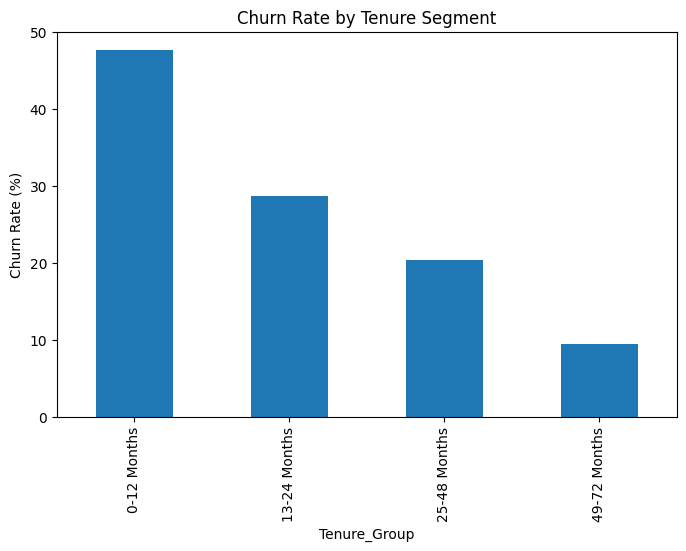

In [12]:
tenure_churn = pd.crosstab(
    df['Tenure_Group'],
    df['Churn'],
    normalize='index'
)*100

print(tenure_churn)

tenure_churn['Yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Tenure Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

In [13]:
df['Charges_Group'] = pd.qcut(
    df['MonthlyCharges'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

Churn                 No        Yes
Charges_Group                      
Low            88.762770  11.237230
Medium         75.424689  24.575311
High           62.492886  37.507114
Very High      67.121729  32.878271


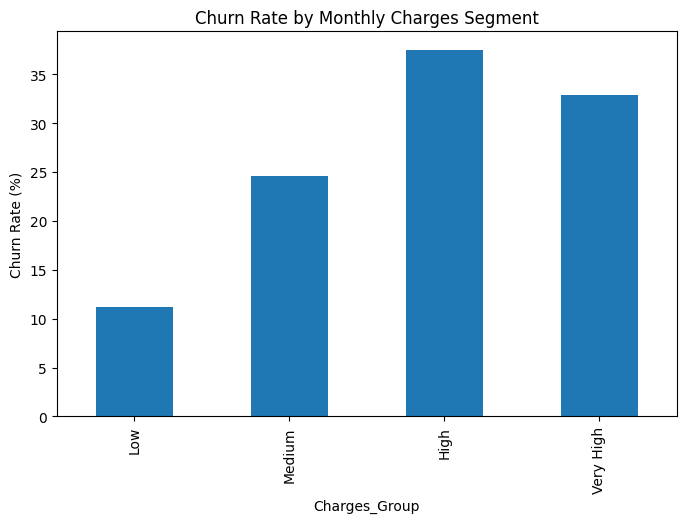

In [14]:
charges_churn = pd.crosstab(
    df['Charges_Group'],
    df['Churn'],
    normalize='index'
)*100

print(charges_churn)

charges_churn['Yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Monthly Charges Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


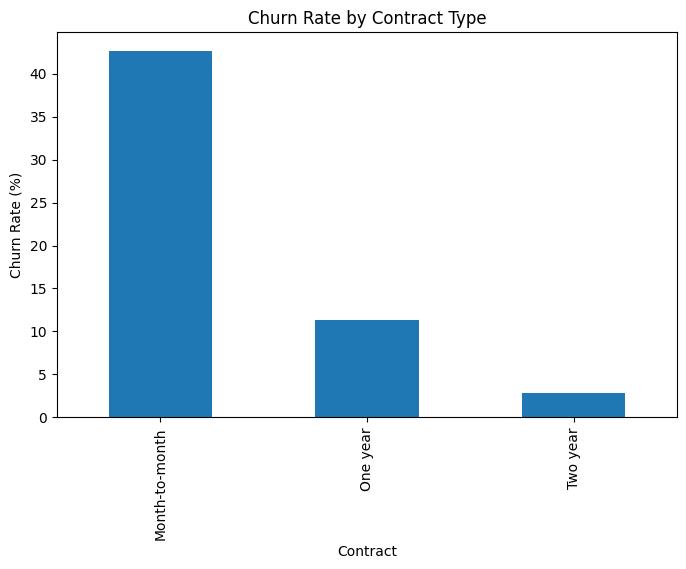

In [15]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100

print(contract_churn)

contract_churn['Yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

In [19]:
df['Churn_Num'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [20]:
print(df[['Churn','Churn_Num']].head())


  Churn  Churn_Num
0    No          0
1    No          0
2   Yes          1
3    No          0
4   Yes          1


In [21]:
segment_analysis = pd.pivot_table(
    df,
    values='Churn_Num',
    index='Tenure_Group',
    columns='Contract',
    aggfunc='mean'
) * 100

print(segment_analysis)

Contract      Month-to-month   One year  Two year
Tenure_Group                                     
0-12 Months        51.354062  10.569106  0.000000
13-24 Months       37.720488   8.121827  0.000000
25-48 Months       32.917706  10.617761  2.189781
49-72 Months       26.023392  12.933754  3.325416


C:\Users\yogen\AppData\Local\Temp\ipykernel_532\2617545189.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  segment_analysis = pd.pivot_table(


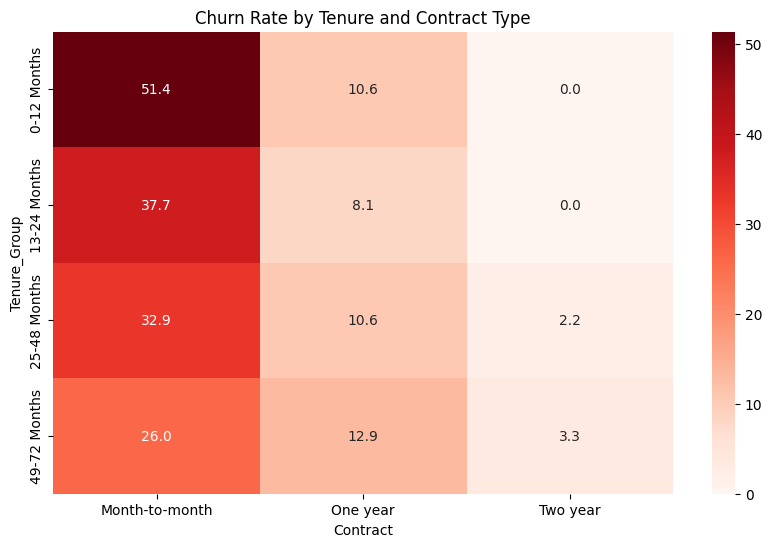

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(
    segment_analysis,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Churn Rate by Tenure and Contract Type')
plt.show()

In [25]:
df['Customer_Segment'] = np.where(
    (df['tenure'] > 36) &
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()),
    'High Value',
    'Regular'
)

Churn                    No        Yes
Customer_Segment                      
High Value        83.323944  16.676056
Regular           70.140471  29.859529


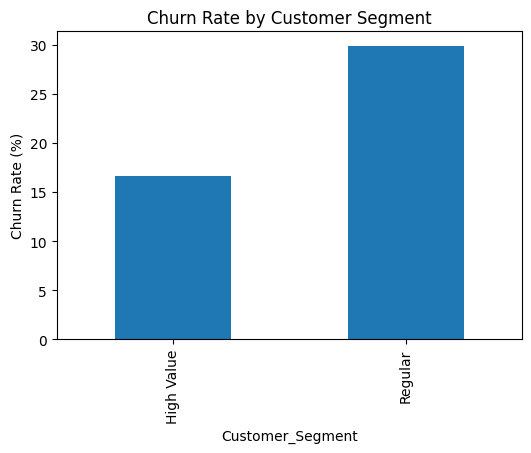

In [26]:
segment_churn = pd.crosstab(
    df['Customer_Segment'],
    df['Churn'],
    normalize='index'
)*100

print(segment_churn)

segment_churn['Yes'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Churn Rate by Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

In [27]:
df['Customer_Segment'] = np.select(
    [
        (df['tenure'] >= 48) & (df['MonthlyCharges'] >= 70),
        (df['tenure'] < 12),
        (df['MonthlyCharges'] >= 70)
    ],
    [
        'High Value',
        'New Customers',
        'Premium Customers'
    ],
    default='Regular Customers'
)

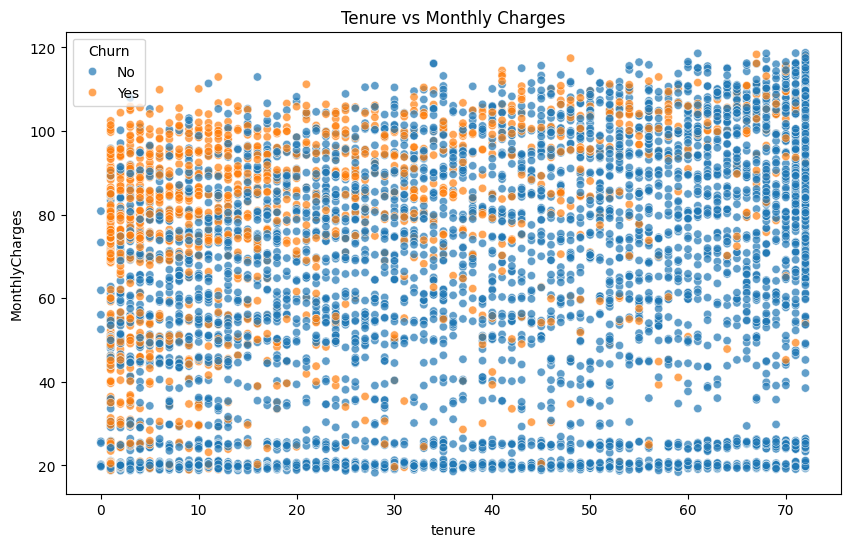

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    alpha=0.7
)

plt.title('Tenure vs Monthly Charges')
plt.show()

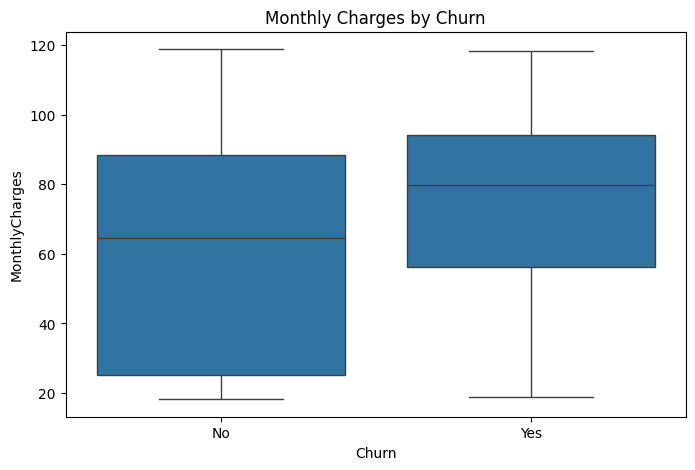

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Churn')
plt.show()

C:\Users\yogen\AppData\Local\Temp\ipykernel_532\652999696.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment = df.groupby('Tenure_Group')['Churn_Num'].mean()*100


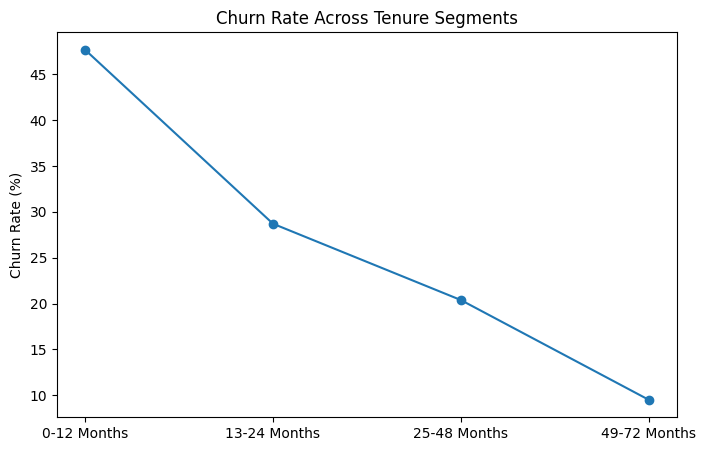

In [31]:
segment = df.groupby('Tenure_Group')['Churn_Num'].mean()*100

plt.figure(figsize=(8,5))

plt.plot(segment.index, segment.values, marker='o')

plt.title('Churn Rate Across Tenure Segments')
plt.ylabel('Churn Rate (%)')
plt.show()

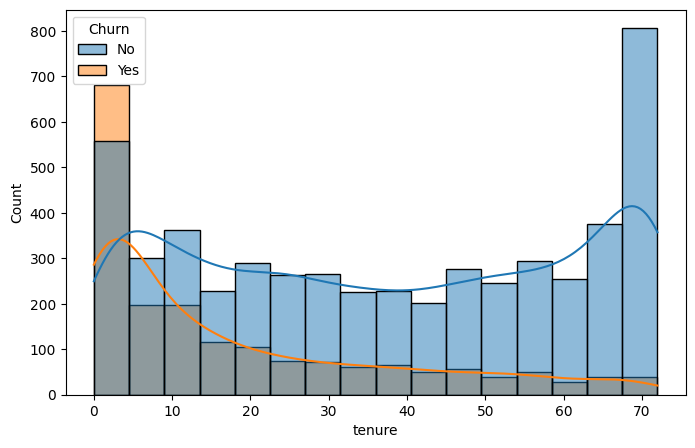

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True
)

plt.show()

TASK:4 Churn Prediction Model

In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("Telco_Customer_Churn_Dataset  (1).csv")

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df.dropna(inplace=True)

In [38]:
df.drop('customerID', axis=1, inplace=True)

In [39]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


Encode Target Variable

In [40]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

In [41]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [42]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

C:\Users\yogen\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [45]:
y_pred = model.predict(X_test)

Model Evaluation

In [46]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 79.6 %


In [47]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", round(precision,3))

Precision: 0.628


In [48]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", round(recall,3))

Recall: 0.57


In [49]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", round(f1,3))

F1 Score: 0.597


In [50]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



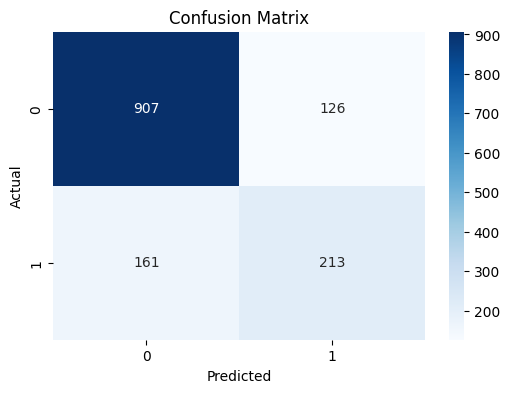

In [51]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

In [52]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance.head(10))

             Feature  Coefficient
15  PaperlessBilling     0.313223
7    InternetService     0.222767
1      SeniorCitizen     0.211764
6      MultipleLines     0.100749
16     PaymentMethod     0.080909
17    MonthlyCharges     0.022606
12       StreamingTV     0.015810
18      TotalCharges     0.000293
13   StreamingMovies    -0.003266
2            Partner    -0.007127


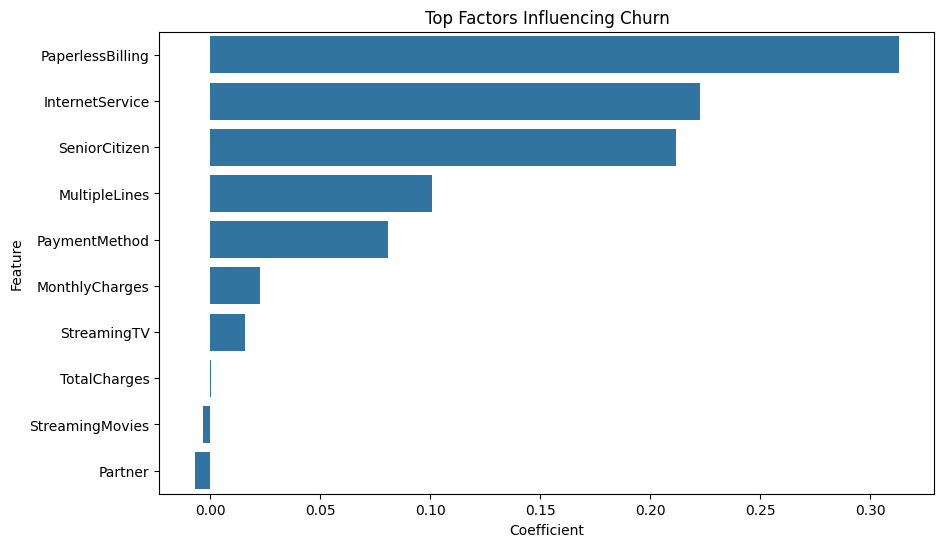

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title(
    'Top Factors Influencing Churn'
)

plt.show()

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print(results_df)

C:\Users\yogen\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.796020   0.628319  0.569519  0.597475
1        Decision Tree  0.712864   0.463054  0.502674  0.482051
2        Random Forest  0.783227   0.617747  0.483957  0.542729


In [55]:
print(
    results_df.sort_values(
        by="Accuracy",
        ascending=False
    )
)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.796020   0.628319  0.569519  0.597475
2        Random Forest  0.783227   0.617747  0.483957  0.542729
1        Decision Tree  0.712864   0.463054  0.502674  0.482051
